In [1]:
# MAE / MSE / RMSE / R²
# 평가 지표의 이해

# 예측은 했는데, 이 모델이 좋은 모델인지 판단이 필요

# 실제값

# 3.0
# 4.0
# 5.0
# 6.0

# 예측값

# 2.8
# 4.2
# 5.3
# 5.5

# 눈으로 판단하기 어려우니, 오차(Error)를 숫자로 계산

📊 평가 지표
MAE  : 0.00
MSE  : 0.00
RMSE : 0.00
R²   : 1.00


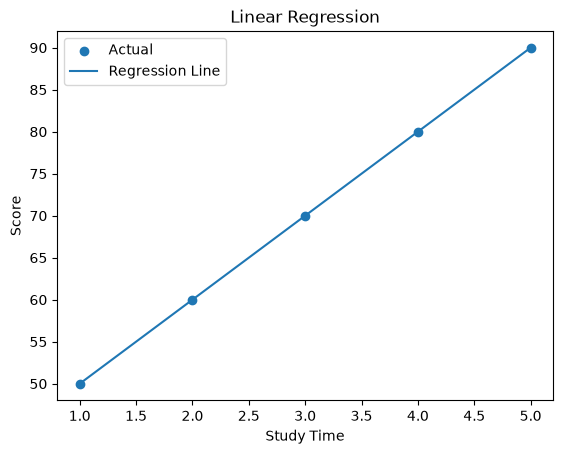

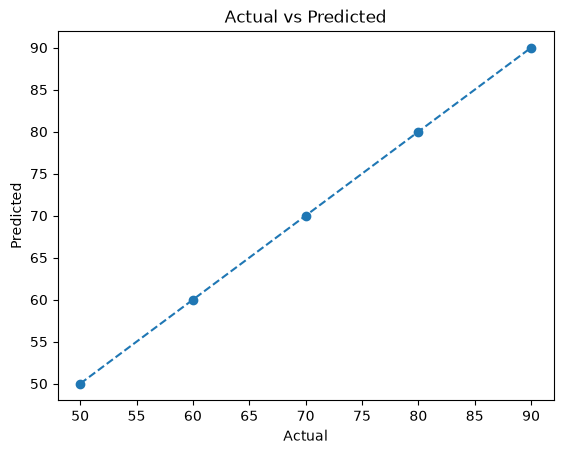

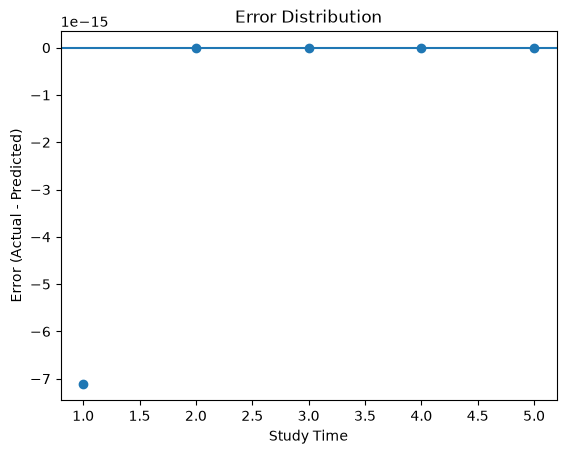

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. 데이터 생성 (공부시간 → 점수)
# -----------------------------

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([50, 60, 70, 80, 90])

# -----------------------------
# 2. 모델 학습
# -----------------------------

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# -----------------------------
# 3. 평가 지표 계산
# -----------------------------

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("📊 평가 지표")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

# -----------------------------
# 4. 시각화 1 (회귀선)
# -----------------------------

plt.figure()
plt.scatter(X, y, label="Actual")
plt.plot(X, y_pred, label="Regression Line")
plt.xlabel("Study Time")
plt.ylabel("Score")
plt.title("Linear Regression")
plt.legend()
plt.show()

# -----------------------------
# 5. 시각화 2 (Actual vs Predicted)
# -----------------------------

plt.figure()
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# -----------------------------
# 6. 시각화 3 (오차 시각화)
# -----------------------------

errors = y - y_pred

plt.figure()
plt.scatter(X, errors)
plt.axhline(0)
plt.xlabel("Study Time")
plt.ylabel("Error (Actual - Predicted)")
plt.title("Error Distribution")
plt.show()

In [ ]:

import seaborn as sns
import numpy as np

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

tips = sns.load_dataset("tips")

# tips.info()

x = tips[["total_bill"]]
y = tips["tip"]

model = LinearRegression()

model.fit(x,y)

print(model.coef_)
print(model.intercept_)

# tip = 0.1×total_bill + 0.9

# 예측
pred = model.predict(x)
pred

# 평가
mae = mean_absolute_error(y,pred)
mse = mean_squared_error(y,pred)
rmse = np.sqrt(mse)
r2 = r2_score(y,pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² :", r2)  # R² = 1 - (오차/전체 분산) / 1에 가까울수록 완벽, 0은 평균, 음수는 평균보다 못함 => 핵심 : 모델이 평균보다 얼마나 더 잘했는지
                    # 모델 오차 : 20, 기준 오차 : 100 일때 R² = 1 - 0.2 = 0.8  => 데이터의 80%를 설명 => 좋은 모델

# 좋은 모델 : 오차 (RMSE)가 적고, 설명력(R²)이 높은 모델

# 결과 해석

# |  지표  |  결과  |         의미         |
# | ----- | ------ |------  ---- ---- ---|
# | MAE   | 0.70   | 평균 오차 약 0.7 달러 |
# | MSE   | 1.03   | 제곱 오차 평균        |
# | RMSE  | 1.02   | 평균 오차 약 1 달러   | => 얼마나 틀렸는지 
# |  R²   | 0.456  | 설명력 약 45.6%      | => 얼마나 잘 설명했는지

# 최종 결론

# 식사금액(total_bill)과 팁(tip)은 양의 관계 존재함.
# 식사금액이 증가할수록 팁도 증가하는 경향 존재함.
# 회귀모델의 설명력(R²)은 약 45.6% 수준임.
# 평균 예측 오차는 약 1달러 수준(RMSE 기준)임.
# 따라서 식사금액만으로 팁을 어느 정도 설명 가능하지만, 성별, 요일, 흡연 여부, 인원수 등의 추가 변수 활용 시 더 좋은 예측모델 구축 가능성 존재
                                            # => 현재 단순 선형회귀로 진행을 했는데 다중 선형회귀로 진행하면 더 좋은 모델이 나온다는 말

[0.10502452]
0.9202696135546731
MAE : 0.7458253894586339
MSE : 1.036019442011377
RMSE : 1.0178504025697377
R² : 0.45661658635167657
